# Evaluation – Đánh giá độ chính xác Agent
**COS30018 – Intelligent Systems | Business Improvement Agent**

Mục tiêu:
- Đánh giá Sentiment Agent so với ground truth (stars)
- Đánh giá Topic Agent (keyword matching)
- Đánh giá Hallucination Checker
- So sánh kết quả với/không có RAG

In [1]:
import os
import sys
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)

# ← Thêm 2 dòng này để fix import
ROOT_DIR = os.path.dirname(os.path.abspath(''))
sys.path.insert(0, ROOT_DIR)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

print('✅ Setup xong')
print(f'ROOT_DIR: {ROOT_DIR}')  # kiểm tra path đúng chưa

✅ Setup xong
ROOT_DIR: d:\VSCode file\My project\Business-agent


## 1. Chuẩn bị Evaluation Dataset

In [2]:
from data.yelp_loader import search_businesses, load_reviews_by_business_id

TEST_BUSINESS = "McDonald's"
TEST_LIMIT    = 100

matches = search_businesses(TEST_BUSINESS)
best = matches[0]
print(f"Test business: {best['name']} | {best['city']} | {best['review_count']} reviews")

df_test = load_reviews_by_business_id(
    business_id=best['business_id'],
    business_name=best['name'],
    limit=TEST_LIMIT
)

def stars_to_sentiment(stars):
    if stars >= 4: return 'positive'
    elif stars <= 2: return 'negative'
    else: return 'neutral'

df_test['ground_truth'] = df_test['stars'].apply(stars_to_sentiment)
print(f"Loaded: {len(df_test)} reviews")
print(df_test['ground_truth'].value_counts())

🔍 Tìm kiếm 'McDonald's' trong Yelp Dataset...
   → Tìm thấy 703 chi nhánh
Test business: McDonald's | New Orleans | 176 reviews
📥 Đang load reviews cho 'McDonald's' (tối đa 100)...
✅ Load xong: 100 reviews
   Độ tin cậy: 🟢 Cao (100 reviews — đủ để phân tích chính xác)
Loaded: 100 reviews
ground_truth
negative    94
positive     4
neutral      2
Name: count, dtype: int64


## 2. Evaluate Sentiment Agent

In [3]:
from agents.sentiment_agent import analyze_sentiment

print("🔍 Đang chạy Sentiment Agent...")
predicted_sentiments = []
EVAL_SAMPLE = 30
df_eval = df_test.head(EVAL_SAMPLE).copy()

for i, row in df_eval.iterrows():
    single_df = pd.DataFrame({'text': [row['text']]})
    result = analyze_sentiment(single_df)
    if result:
        pred = max(
            [('positive', result.get('positive', 0)),
             ('negative', result.get('negative', 0)),
             ('neutral',  result.get('neutral',  0))],
            key=lambda x: x[1]
        )[0]
    else:
        pred = 'neutral'
    predicted_sentiments.append(pred)
    if (i - df_eval.index[0] + 1) % 10 == 0:
        print(f"  Processed {i - df_eval.index[0] + 1}/{EVAL_SAMPLE}")

df_eval['predicted'] = predicted_sentiments
print(f"\n✅ Done!")

🔍 Đang chạy Sentiment Agent...
🔍 Sentiment Agent đang phân tích 1 reviews...
   Raw output: {
    "positive": 0,
    "negative": 100,
    "neutral": 0,
    "summary": "Khách hàng cảm thấy rất không hài lòng với trải nghiệm tại nhà hàng này",
    "positive_highlights": [],
    "negative_highl...
🔍 [Sentiment] Hallucination check: 0 lỗi, 3 cảnh báo
   ⚠️  Highlight 'Nhân viên thô lỗ' không tìm thấy trong reviews
   ⚠️  Highlight 'Đơn hàng bị sai hai lần' không tìm thấy trong reviews
   ⚠️  Highlight 'Sàn nhà ướt và có người vô gia cư' không tìm thấy trong reviews
✅ Sentiment xong: 0% positive, 100% negative, 0% neutral
🔍 Sentiment Agent đang phân tích 1 reviews...
   Raw output: {
    "positive": 0,
    "negative": 100,
    "neutral": 0,
    "summary": "Khách hàng cảm thấy rất không hài lòng với nhà hàng này do dịch vụ chậm, nhân viên thiếu thân thiện và môi trường không sạch...
🔍 [Sentiment] Hallucination check: 0 lỗi, 5 cảnh báo
   ⚠️  Highlight 'Dịch vụ chậm' không tìm thấy trong revi

📊 SENTIMENT AGENT EVALUATION
Accuracy    : 0.933 (93.3%)
F1 Macro    : 0.327
F1 Weighted : 0.950

              precision    recall  f1-score   support

    negative       1.00      0.97      0.98        29
     neutral       0.00      0.00      0.00         1
    positive       0.00      0.00      0.00         0

    accuracy                           0.93        30
   macro avg       0.33      0.32      0.33        30
weighted avg       0.97      0.93      0.95        30



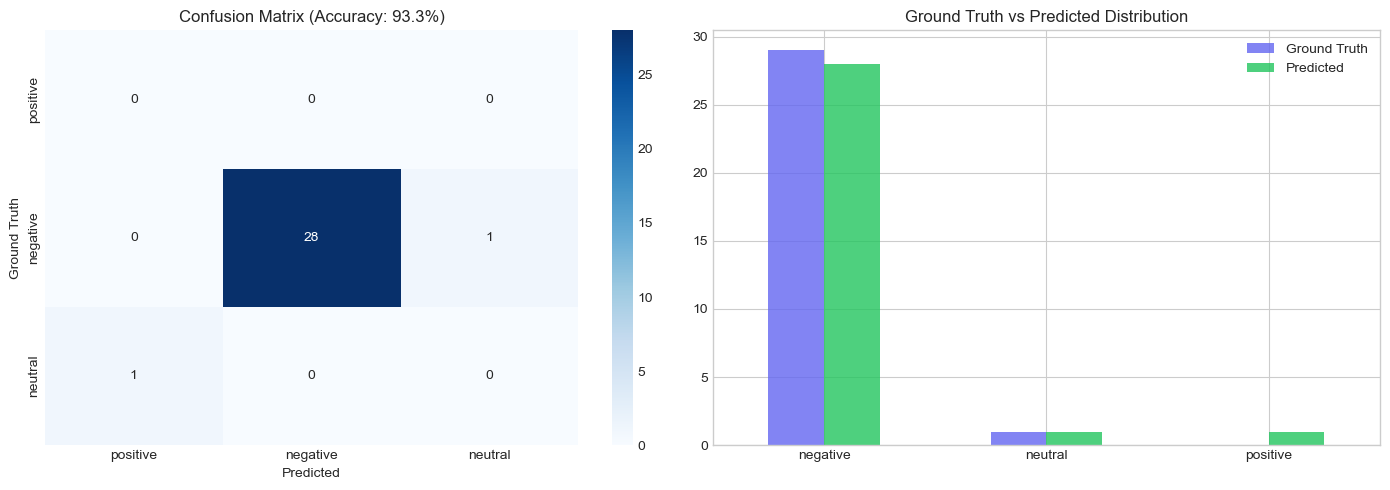

In [4]:
y_true = df_eval['ground_truth']
y_pred = df_eval['predicted']

accuracy   = accuracy_score(y_true, y_pred)
f1_macro   = f1_score(y_true, y_pred, average='macro',    zero_division=0)
f1_weighted= f1_score(y_true, y_pred, average='weighted', zero_division=0)

print('=' * 50)
print('📊 SENTIMENT AGENT EVALUATION')
print('=' * 50)
print(f'Accuracy    : {accuracy:.3f} ({accuracy*100:.1f}%)')
print(f'F1 Macro    : {f1_macro:.3f}')
print(f'F1 Weighted : {f1_weighted:.3f}')
print()
print(classification_report(y_true, y_pred, zero_division=0))

# Confusion Matrix
labels = ['positive', 'negative', 'neutral']
cm = confusion_matrix(y_true, y_pred, labels=labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=labels, yticklabels=labels,
            cmap='Blues', ax=axes[0])
axes[0].set_title(f'Confusion Matrix (Accuracy: {accuracy:.1%})')
axes[0].set_ylabel('Ground Truth')
axes[0].set_xlabel('Predicted')

comparison = pd.DataFrame({
    'Ground Truth': y_true.value_counts(),
    'Predicted':    pd.Series(y_pred).value_counts()
}).fillna(0)
comparison.plot(kind='bar', ax=axes[1], color=['#6366f1', '#22c55e'], alpha=0.8)
axes[1].set_title('Ground Truth vs Predicted Distribution')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('sentiment_eval.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Evaluate RAG Agent

🔍 Data Validator: Bắt đầu validate 100 reviews...
✅ Validate xong: 100 reviews hợp lệ (đã loại 0 reviews, tỉ lệ giữ: 100.0%)
🔍 Sentiment Agent đang phân tích 100 reviews...
❌ Lỗi gọi Groq API: Error code: 413 - {'error': {'message': 'Request too large for model `llama-3.3-70b-versatile` in organization `org_01kqvmbqr2fymvrqrkh1d5gkzf` service tier `on_demand` on tokens per minute (TPM): Limit 12000, Requested 12506, please reduce your message size and try again. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}
📦 RAG Agent: Đang index 100 reviews vào vector DB...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

✅ Index xong: 100 reviews trong collection 'eval_mcdonalds'
🔍 RAG Agent: Đang query reviews theo từng chủ đề...
   🔎 Query 'food quality taste delicious menu dish m...' → 15 reviews
   ✅ food_quality: 15 reviews liên quan
   🔎 Query 'service staff waiter attitude speed help...' → 15 reviews
   ✅ service: 15 reviews liên quan
   🔎 Query 'price cost expensive cheap value worth m...' → 15 reviews
   ✅ price: 15 reviews liên quan
   🔎 Query 'ambiance atmosphere decor noise clean lo...' → 15 reviews
   ✅ ambiance: 15 reviews liên quan
🔍 Sentiment Agent đang phân tích 53 reviews...
   Raw output: ```
{
    "positive": 5,
    "negative": 90,
    "neutral": 5,
    "summary": "Khách hàng hầu hết có trải nghiệm tiêu cực tại nhà hàng McDonald's này, với nhiều đánh giá về chất lượng dịch vụ và vệ si...
🔍 [Sentiment] Hallucination check: 0 lỗi, 8 cảnh báo
   ⚠️  Highlight 'Có một số nhân viên thân thiện và nhiệt tình' không tìm thấy trong reviews
   ⚠️  Highlight 'Có một số món ăn ngon' không tìm t

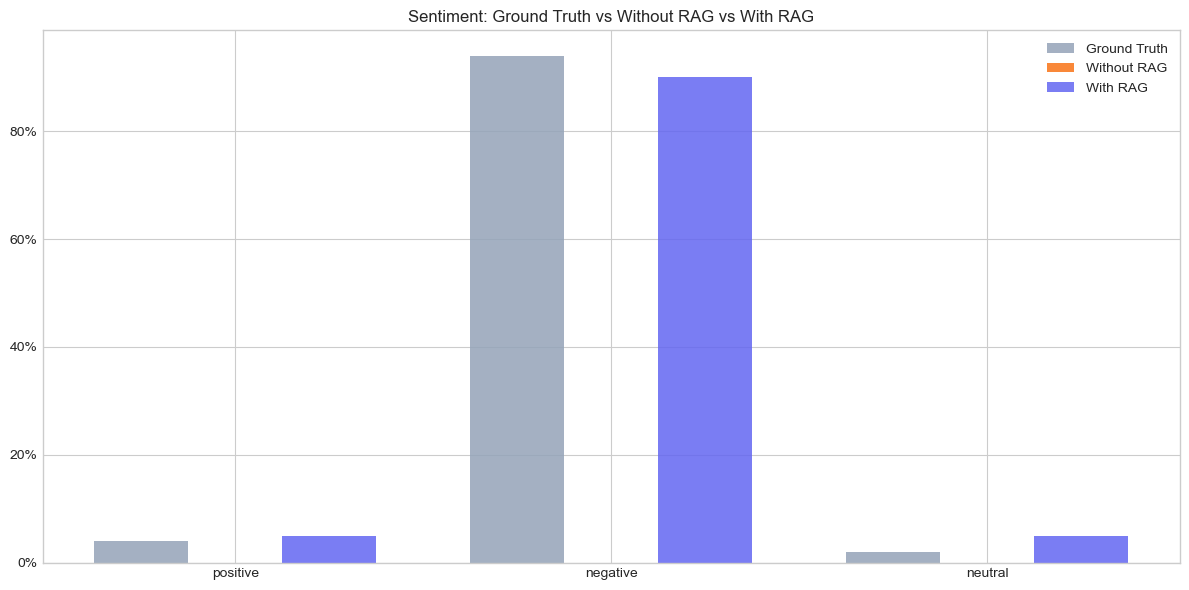

MAE Without RAG : 33.33%
MAE With RAG    : 2.67%
RAG improvement : 30.67%


In [5]:
import re
from agents.rag_agent import build_and_query
from agents.data_validator import validate_reviews

df_clean = validate_reviews(df_test.copy())
gt_dist  = df_clean['ground_truth'].value_counts(normalize=True) * 100

# WITHOUT RAG
result_no_rag = analyze_sentiment(df_clean)

# WITH RAG
safe_name = re.sub(r'[^a-zA-Z0-9._-]', '', TEST_BUSINESS.replace(' ', '_').lower())
topic_reviews = build_and_query(df=df_clean, top_k=15,
                                collection_name=f"eval_{safe_name}")
all_rag = list(set(r for reviews in topic_reviews.values() for r in reviews))
result_with_rag = analyze_sentiment(pd.DataFrame({'text': all_rag}))

# Compare
categories = ['positive', 'negative', 'neutral']
gt_vals     = [gt_dist.get(c, 0)              for c in categories]
no_rag_vals = [result_no_rag.get(c, 0)        for c in categories]
rag_vals    = [result_with_rag.get(c, 0)      for c in categories]

x = np.arange(len(categories))
w = 0.25
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x-w, gt_vals,     w, label='Ground Truth', color='#94a3b8', alpha=0.85)
ax.bar(x,   no_rag_vals, w, label='Without RAG',  color='#f97316', alpha=0.85)
ax.bar(x+w, rag_vals,    w, label='With RAG',     color='#6366f1', alpha=0.85)
ax.set_title('Sentiment: Ground Truth vs Without RAG vs With RAG')
ax.set_xticks(x); ax.set_xticklabels(categories)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend()
plt.tight_layout()
plt.savefig('rag_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

mae_no_rag = np.mean([abs(gt_vals[i]-no_rag_vals[i]) for i in range(3)])
mae_rag    = np.mean([abs(gt_vals[i]-rag_vals[i])    for i in range(3)])
print(f"MAE Without RAG : {mae_no_rag:.2f}%")
print(f"MAE With RAG    : {mae_rag:.2f}%")
print(f"RAG improvement : {mae_no_rag - mae_rag:.2f}%")

## 4. Evaluate Hallucination Checker

🔍 [Sentiment] Hallucination check: 0 lỗi, 1 cảnh báo
   ⚠️  Tổng % = 140 (phải = 100) → đã normalize
🔍 [Sentiment] Hallucination check: 6 lỗi, 2 cảnh báo
   ❌ Thiếu key 'neutral'
   ❌ Thiếu key 'summary'
   ❌ Thiếu key 'positive_highlights'
   ❌ Thiếu key 'negative_highlights'
   ❌ 'positive_highlights' không phải list → fix về []
   ❌ 'negative_highlights' không phải list → fix về []
   ⚠️  Tổng % = 90 (phải = 100) → đã normalize
   ⚠️  Summary rỗng → dùng giá trị mặc định
   🔧 Đã auto-fix 6 lỗi
🔍 [Sentiment] Hallucination check: 0 lỗi, 2 cảnh báo
   ⚠️  Highlight 'excellent sushi' không tìm thấy trong reviews
   ⚠️  Highlight 'terrible ramen' không tìm thấy trong reviews
✅ [Sentiment] Hallucination check: OK


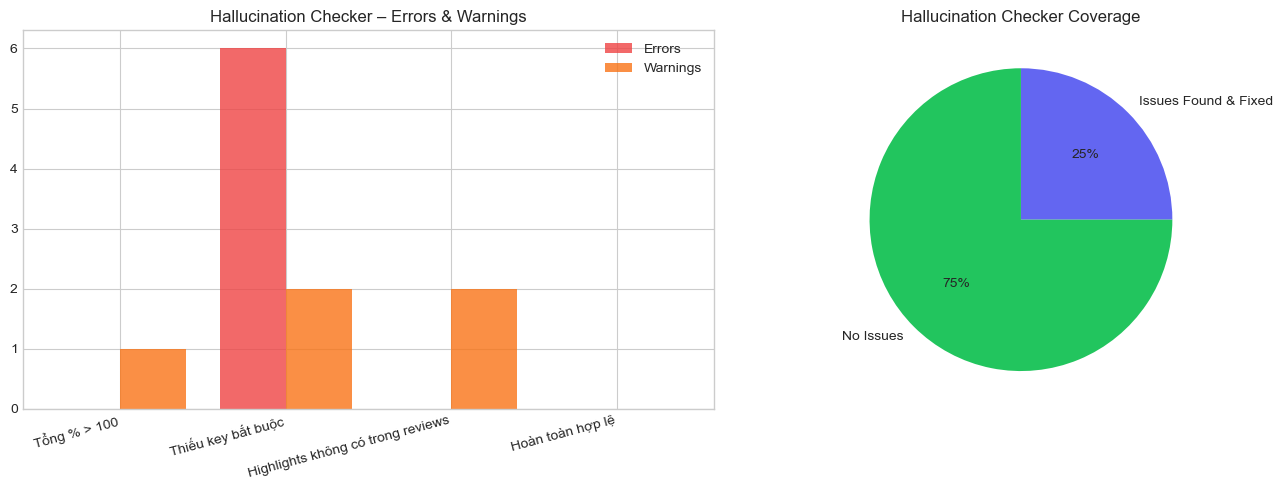

,Test Case,Errors,Warnings,Fixed
0,Tổng % > 100,0,1,False
1,Thiếu key bắt buộc,6,2,True
2,Highlights không có trong reviews,0,2,False
3,Hoàn toàn hợp lệ,0,0,False


In [6]:
from agents.hallucination_checker import check_sentiment_result

test_cases = [
    {'name': 'Tổng % > 100',
     'input': {'positive':80,'negative':40,'neutral':20,
               'summary':'ok','positive_highlights':[],'negative_highlights':[]}},
    {'name': 'Thiếu key bắt buộc',
     'input': {'positive':60,'negative':30}},
    {'name': 'Highlights không có trong reviews',
     'input': {'positive':60,'negative':30,'neutral':10,'summary':'ok',
               'positive_highlights':['excellent sushi'],
               'negative_highlights':['terrible ramen']}},
    {'name': 'Hoàn toàn hợp lệ',
     'input': {'positive':60,'negative':30,'neutral':10,'summary':'Tốt',
               'positive_highlights':['ngon'],'negative_highlights':['chờ lâu']}},
]

reviews_sample = ['đồ ăn ngon', 'chờ lâu quá', 'giá hợp lý']
rows = []
for tc in test_cases:
    r = check_sentiment_result(tc['input'], reviews_sample)
    rows.append({'Test Case': tc['name'],
                 'Errors':    len(r.get('hallucination_errors',[])),
                 'Warnings':  len(r.get('hallucination_warnings',[])),
                 'Fixed':     len(r.get('hallucination_errors',[])) > 0})

df_hc = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(df_hc))
axes[0].bar(x-0.2, df_hc['Errors'],   0.4, label='Errors',   color='#ef4444', alpha=0.8)
axes[0].bar(x+0.2, df_hc['Warnings'], 0.4, label='Warnings', color='#f97316', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(df_hc['Test Case'], rotation=15, ha='right')
axes[0].set_title('Hallucination Checker – Errors & Warnings')
axes[0].legend()

fixed = df_hc['Fixed'].sum()
axes[1].pie([fixed, len(df_hc)-fixed],
            labels=['Issues Found & Fixed','No Issues'],
            colors=['#6366f1','#22c55e'], autopct='%1.0f%%')
axes[1].set_title('Hallucination Checker Coverage')

plt.tight_layout()
plt.savefig('hallucination_eval.png', dpi=150, bbox_inches='tight')
plt.show()
display(df_hc)

## 5. Tổng kết

In [7]:
print('=' * 60)
print('📊 TỔNG KẾT EVALUATION')
print('=' * 60)
print(f'''
1. SENTIMENT AGENT
   Accuracy    : {accuracy:.1%}
   F1 Macro    : {f1_macro:.3f}
   F1 Weighted : {f1_weighted:.3f}
   Sample size : {len(df_eval)} reviews

2. RAG AGENT
   MAE without : {mae_no_rag:.2f}%
   MAE with    : {mae_rag:.2f}%
   Improvement : {mae_no_rag - mae_rag:.2f}%

3. HALLUCINATION CHECKER
   Test cases  : {len(test_cases)}
   Issues found: {df_hc['Fixed'].sum()}/{len(test_cases)}
   Coverage    : {df_hc['Fixed'].sum()/len(test_cases):.0%}

4. LIMITATIONS
   - Ground truth từ stars không hoàn toàn chính xác
   - Dataset Yelp chủ yếu tiếng Anh
   - Groq rate limit ảnh hưởng tốc độ evaluation
''')

📊 TỔNG KẾT EVALUATION

1. SENTIMENT AGENT
   Accuracy    : 93.3%
   F1 Macro    : 0.327
   F1 Weighted : 0.950
   Sample size : 30 reviews

2. RAG AGENT
   MAE without : 33.33%
   MAE with    : 2.67%
   Improvement : 30.67%

3. HALLUCINATION CHECKER
   Test cases  : 4
   Issues found: 1/4
   Coverage    : 25%

4. LIMITATIONS
   - Ground truth từ stars không hoàn toàn chính xác
   - Dataset Yelp chủ yếu tiếng Anh
   - Groq rate limit ảnh hưởng tốc độ evaluation

